In [1]:
from importlib import reload
import sys
import subprocess

import scipy
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../python")
import pymodelica
reload(pymodelica)


<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

# Run the simualtion

In [39]:
MODEL_EXE_NAME = "System_LMO_exe"
MODEL_FILE = "../System_LMO.mo"
MODEL_FILE_LIN = "../build/linearized_model.py"
MODEL_RESULT = f'../build/{MODEL_EXE_NAME}_res_init.mat'
EQUILIBRIUM_TIME = 20.0
# PARAMS = "../parameters/params_lmo_v1_mod_tes.txt"
PARAMS = "../parameters/params_lmo_v1_mod_absorber.txt"
# PARAMS = "../parameters/params_lmo_v1_default.txt"
# PARAMS = "../parameters/params.txt"


# Step 1. a fast simulation to reach equilibrium and generate fake data


In [5]:
log = subprocess.run(
    [
        f"./{MODEL_EXE_NAME}",
        # "-lv=-LOG_STDOUT",
        f"-overrideFile={PARAMS}",
        "-startTime=0",
        f"-stopTime={EQUILIBRIUM_TIME}",
        "-stepSize=2e-4",
        "-tolerance=1e-8",
        "-s=dassl",
        "-w", # Show all warnings
        "-outputFormat=mat",
        f"-r={MODEL_EXE_NAME}_res_init.mat", # Result filename
        f"-l={EQUILIBRIUM_TIME}", ## Perform linearization
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log.stderr, log.stdout


('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K7 with a small value or zero.\n|                 | |       |

In [40]:
reload(pymodelica)

<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

In [41]:
model = pymodelica.TESModel(MODEL_FILE_LIN, 
                 MODEL_FILE, 
                 MODEL_RESULT,
                 config={"L": 0.3e-6, "RL": 0.02}, 
                 f_min = 1, f_max = 100e3, points = 1000)

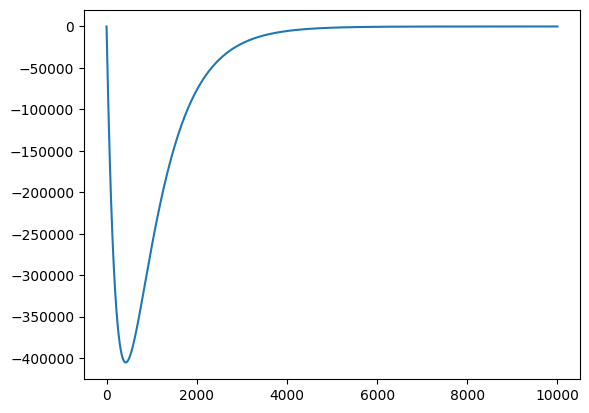

In [43]:
t,y = model.get_impulse(index_cinput = 10, T=np.linspace(0,0.1,10000))
plt.plot(y[:,1])

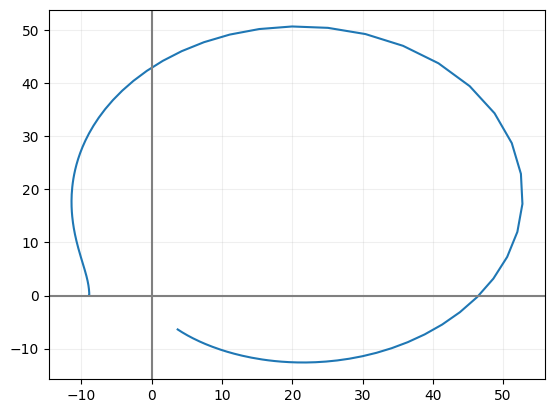

In [44]:
dIdV = model.get_dIdV()
plt.plot(dIdV.real, dIdV.imag)
plt.grid(alpha=0.2)
plt.axhline(0,color="grey")
plt.axvline(0,color="grey")